### Orchestrator-Worker
In the orchestrator-workers workflow, a central LLM dynamically breaks down tasks, delegates them to worker LLMs, and synthesizes their results.

When to use this workflow: This workflow is well-suited for complex tasks where you can’t predict the subtasks needed (in coding, for example, the number of files that need to be changed and the nature of the change in each file likely depend on the task). Whereas it’s topographically similar, the key difference from parallelization is its flexibility—subtasks aren't pre-defined, but determined by the orchestrator based on the specific input.

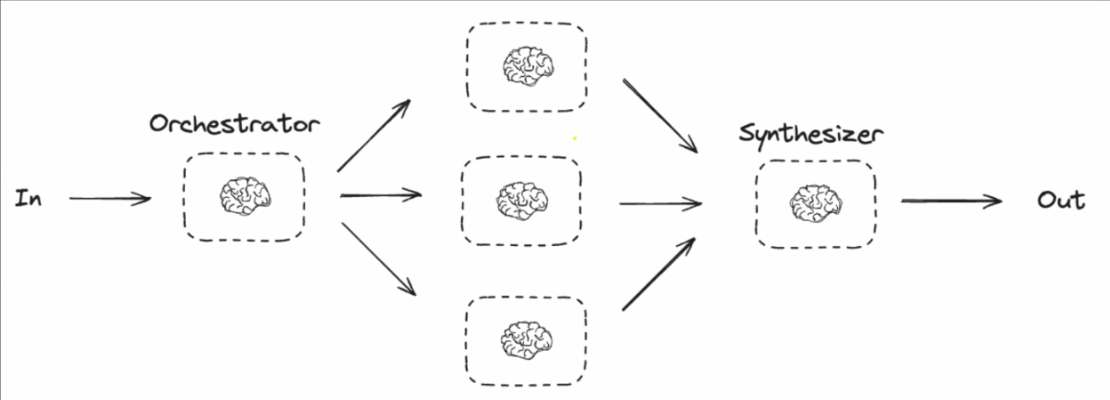

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_nvidia_ai_endpoints import ChatNVIDIA

os.environ['NVIDIA_API_KEY'] = os.getenv('NVIDIA_API_KEY')
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ['LANGCHAIN_TRACING_V2'] = "true"
os.environ['LANGCHAIN_PROJECT'] = "Orchestrator"

from langchain_nvidia_ai_endpoints import ChatNVIDIA

llm = ChatNVIDIA(
  model="openai/gpt-oss-20b",
  api_key=os.getenv('NVIDIA_API_KEY'), 
  temperature=1,
  top_p=1,
  max_completion_tokens=4096,
)

In [2]:
import logging
import operator
from dataclasses import dataclass
from typing import Annotated, List

from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.constants import Send
from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, Field
from typing_extensions import TypedDict

C:\Users\singh\AppData\Local\Temp\ipykernel_21632\1841241956.py:7: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


In [3]:
# Logging
# ─────────────────────────────────────────────
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

MAX_SECTIONS = 8

In [4]:
class Section(BaseModel):
    name: str = Field(description="Name for this section of the report")
    description: str = Field(
        description="Brief overview of the main topics and concepts of the section"
    )

class Sections(BaseModel):
    sections: List[Section] = Field(description="Sections of the report")

planner = llm.with_structured_output(Sections)

### Creating Workers Dynamically In Langgraph 
Because orchestrator-worker workflows are common, LangGraph has the Send API to support this. It lets you dynamically create worker nodes and send each one a specific input. Each worker has its own state, and all worker outputs are written to a shared state key that is accessible to the orchestrator graph. This gives the orchestrator access to all worker output and allows it to synthesize them into a final output. As you can see below, we iterate over a list of sections and Send each to a worker node. 

In [5]:
class State(TypedDict):
    topic: str
    sections: List[Section]
    # Each entry is a (index, content) tuple so sections can be re-ordered
    # after parallel workers finish in arbitrary order
    completed_sections: Annotated[list, operator.add]
    final_report: str

class WorkerState(TypedDict):
    section: Section
    index: int  # preserves original section order
    completed_sections: Annotated[list, operator.add]

In [6]:
def orchestrator(state: State) -> dict:
    """Plans the report structure by generating a list of sections."""

    report_sections = planner.invoke(
        [
            SystemMessage(
                content=(
                    "You are an expert report planner. "
                    "Generate between 4 and 8 well-structured sections for a professional report. "
                    "Each section must have a clear, specific name and a concise description of what it will cover. "
                    "Ensure sections are distinct with minimal overlap, and flow logically from introduction to conclusion."
                )
            ),
            HumanMessage(content=f"Report topic: {state['topic']}"),
        ]
    )

    sections = report_sections.sections[:MAX_SECTIONS]
    logger.info("Planned %d sections: %s", len(sections), [s.name for s in sections])
    return {"sections": sections}


def llm_call(state: WorkerState) -> dict:
    """Worker node: writes a single report section."""

    section = llm.invoke(
        [
            SystemMessage(
                content=(
                    "You are a professional technical writer. "
                    "Write a detailed, well-structured report section based on the provided name and description. "
                    "Use clear prose with subheadings where appropriate. "
                    "Do not include any preamble, meta-commentary, or references to these instructions."
                )
            ),
            HumanMessage(
                content=(
                    f"Section name: {state['section'].name}\n"
                    f"Section description: {state['section'].description}"
                )
            ),
        ]
    )

    logger.info("Completed section [%d]: %s", state["index"], state["section"].name)
    # Store as (index, content) tuple to allow deterministic ordering later
    return {"completed_sections": [(state["index"], section.content)]}


def synthesizer(state: State) -> dict:
    """Merges all sections into a single, coherent final report using the LLM."""

    # Sort sections by their original planned order before merging
    sorted_sections = sorted(state["completed_sections"], key=lambda x: x[0])
    ordered_content = "\n\n---\n\n".join(content for _, content in sorted_sections)

    final_report = llm.invoke(
        [
            SystemMessage(
                content=(
                    "You are a professional editor. You will receive a set of report sections separated by '---'. "
                    "Your job is to merge them into a single, polished, cohesive report. "
                    "Ensure consistent tone and voice throughout, smooth transitions between sections, "
                    "a compelling introduction, and a strong conclusion. "
                    "Preserve all technical detail from the original sections."
                )
            ),
            HumanMessage(
                content=(
                    f"Report topic: {state['topic']}\n\n"
                    f"Sections to merge:\n\n{ordered_content}"
                )
            ),
        ]
    )

    logger.info("Final report synthesized successfully.")
    return {"final_report": final_report.content}

# ─────────────────────────────────────────────
# Conditional edge
# ─────────────────────────────────────────────
def assign_workers(state: State) -> list:
    """Fans out one llm_call worker per section, capped at MAX_SECTIONS."""
    return [
        Send("llm_call", {"section": s, "index": i})
        for i, s in enumerate(state["sections"])
    ]

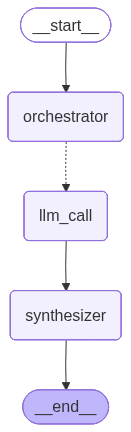

In [8]:
from IPython.display import Image, display

# Graph
# ─────────────────────────────────────────────
builder = StateGraph(State)

builder.add_node("orchestrator", orchestrator)
builder.add_node("llm_call", llm_call)
builder.add_node("synthesizer", synthesizer)

builder.add_edge(START, "orchestrator")
builder.add_conditional_edges("orchestrator", assign_workers, ["llm_call"])
builder.add_edge("llm_call", "synthesizer")
builder.add_edge("synthesizer", END)

graph = builder.compile()

# Show the workflow
display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
result = graph.invoke({"topic": "The impact of AI on modern healthcare"})
print(result["final_report"])

INFO:__main__:Planned 6 sections: ['Executive Summary', 'Introduction & Scope', 'Clinical Applications and Outcomes', 'Economic Impact and ROI', 'Ethical, Legal, and Regulatory Landscape', 'Strategic Recommendations & Future Outlook']
INFO:__main__:Completed section [0]: Executive Summary
INFO:__main__:Completed section [1]: Introduction & Scope
INFO:__main__:Completed section [2]: Clinical Applications and Outcomes
INFO:__main__:Completed section [4]: Ethical, Legal, and Regulatory Landscape
INFO:__main__:Completed section [5]: Strategic Recommendations & Future Outlook
INFO:__main__:Completed section [3]: Economic Impact and ROI
INFO:__main__:Final report synthesized successfully.


**The Impact of AI on Modern Healthcare**  
*July 2026*  

---

### Executive Summary  

Artificial Intelligence (AI) is reshaping every stratum of contemporary medicine—from accelerating image‑based diagnosis to predicting disease trajectories and streamlining health‑system operations.  Across the globe, the most compelling evidence converges on a few key gains:

| Domain | Impact | Evidence |
|--------|--------|----------|
| **Diagnostic Accuracy & Speed** | Sensitivity ↑ 15‑25 % ; processing time ↓ 40 % | Large, prospective trials in radiology, dermatology and pathology |
| **Predictive Analytics** | AUC > 0.85 for sepsis, readmission, progression | 0.82‑0.90 AUC in validated research |
| **Personalised Treatment** | Tailored pharmacotherapy with higher adherence and survival | Meta‑analyses demonstrate 2‑3 year benefits for early‑stage cancers |
| **Operational Efficiency** | Administrative cost ↓ 20‑30 % | Automated triage, robotics, and chat‑bots |
| **Cost Implications** | 5‑10 

In [10]:
result = graph.invoke({"topic": "Create a report on Agentic AI RAG"})
print(result["final_report"])

INFO:__main__:Planned 7 sections: ['1. Introduction to Agentic RAG', '2. Architectural Blueprint', '3. Use‑Case Landscape', '4. Governance & Risk Management', '5. Performance & Evaluation Framework', '6. Operational Deployment Strategies', '7. Outlook & Open Challenges']
INFO:__main__:Completed section [6]: 7. Outlook & Open Challenges
INFO:__main__:Completed section [3]: 4. Governance & Risk Management
INFO:__main__:Completed section [0]: 1. Introduction to Agentic RAG
INFO:__main__:Completed section [1]: 2. Architectural Blueprint
INFO:__main__:Completed section [4]: 5. Performance & Evaluation Framework
INFO:__main__:Completed section [5]: 6. Operational Deployment Strategies
INFO:__main__:Completed section [2]: 3. Use‑Case Landscape
INFO:__main__:Final report synthesized successfully.


---

# Agentic Retrieval‑Augmented Generation (Agentic RAG)

## Executive Summary  

Retrieval‑Augmented Generation (RAG) has long been the go‑to strategy for grounding large language models in external knowledge. **Agentic RAG** transforms the retrieval step from a deterministic lookup into an autonomous, learning agent that strategizes, explores, and adapts during inference. By treating retrieval as a decision‑making policy, Agentic RAG delivers higher factual fidelity, personalized reasoning, and dynamic knowledge updates—all while remaining amenable to rigorous governance and cost‑efficient deployment.  

This report offers a complete technical, ethical, and operational blueprint for building, evaluating, and shipping industrial‑scale Agentic RAG systems. It covers architectural design, real‑world use cases, governance frameworks, performance metrics, scalable rollout practices, and the most pressing research frontiers.

> **Key take‑aways**  
> •  The agent’s *policy network* lear